In [13]:
# ============================================
# БЛОК 0: УСТАНОВКА И ИМПОРТ БИБЛИОТЕК
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Для PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Для TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("All libraries imported successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"TensorFlow version: {tf.__version__}")

I0000 00:00:1775111447.960504   33279 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775111447.965814   33279 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775111448.381807   33279 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775111451.878427   33279 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

All libraries imported successfully!
PyTorch version: 2.9.1+cpu
TensorFlow version: 2.21.0


In [14]:
# ============================================
# БЛОК 1: ЗАГРУЗКА И ПОДГОТОВКА ДАННЫХ
# ============================================

# Загрузка данных
df = pd.read_excel('bcf_data.xlsx')

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

# Определение признаков и цели
feature_columns = ['logBCF', 'logKOW', 'nHM', 'piPC09', 'PCD', 'X2Av', 
                   'MLOGP', 'ON1V', 'N-072', 'B02[C-N]', 'F04[C-O]']
target_column = 'Class'

# Извлечение данных
X = df[feature_columns].values
y = df[target_column].values

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Unique classes: {np.unique(y)}")

# Кодирование целевой переменной
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"\nEncoded classes: {label_encoder.classes_}")
print(f"Encoded labels mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(f"  {class_name} -> {i}")

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Масштабирование признаков
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set size: {X_train_scaled.shape[0]}")
print(f"Test set size: {X_test_scaled.shape[0]}")
print(f"Number of features: {X_train_scaled.shape[1]}")
print(f"Number of classes: {len(label_encoder.classes_)}")

# Сохраняем для дальнейшего использования
class_names = [str(c) for c in label_encoder.classes_]
y_train_int = y_train.astype(int)
y_test_int = y_test.astype(int)

Dataset shape: (779, 15)

First few rows:
        CAS                              SMILES    Set  logBCF  logKOW  nHM  \
0  100-02-7             O=[N+](c1ccc(cc1)O)[O-]  Train   0.735    1.91    0   
1  100-17-4            O=[N+](c1ccc(cc1)OC)[O-]  Train   0.930    2.03    0   
2  100-18-5                c1cc(ccc1C(C)C)C(C)C  Train   3.240    5.23    0   
3  100-25-4  O=[N+]([O-])c1ccc(cc1)[N+](=O)[O-]  Train  -0.400    1.46    0   
4  100-40-3                        C=CC1CCC=CC1  Train   2.235    3.93    0   

   piPC09    PCD   X2Av  MLOGP   ON1V  N-072  B02[C-N]  F04[C-O]  Class  
0     0.0  1.485  0.136  1.348  0.722      0         1         5      1  
1     0.0  1.469  0.140  1.701  0.881      0         1         5      1  
2     0.0  1.201  0.249  4.135  2.056      0         0         0      3  
3     0.0  1.692  0.127  1.886  0.789      0         1         8      3  
4     0.0  0.517  0.253  2.646  1.306      0         0         0      1  

Column names:
['CAS', 'SMILES', 'Set',


TRAINING PERCEPTRON FROM SCRATCH
Training perceptron from scratch...
  Iteration 200/1000, Loss: 0.8308, Accuracy: 0.7095
  Iteration 400/1000, Loss: 0.7436, Accuracy: 0.7159
  Iteration 600/1000, Loss: 0.6970, Accuracy: 0.7271
  Iteration 800/1000, Loss: 0.6660, Accuracy: 0.7335
  Iteration 1000/1000, Loss: 0.6428, Accuracy: 0.7384

RESULTS - PERCEPTRON FROM SCRATCH
Test Accuracy: 0.7308 (73.08%)

Classification Report:
              precision    recall  f1-score   support

           1       0.71      0.92      0.80        92
           2       0.00      0.00      0.00        13
           3       0.81      0.57      0.67        51

    accuracy                           0.73       156
   macro avg       0.50      0.50      0.49       156
weighted avg       0.68      0.73      0.69       156



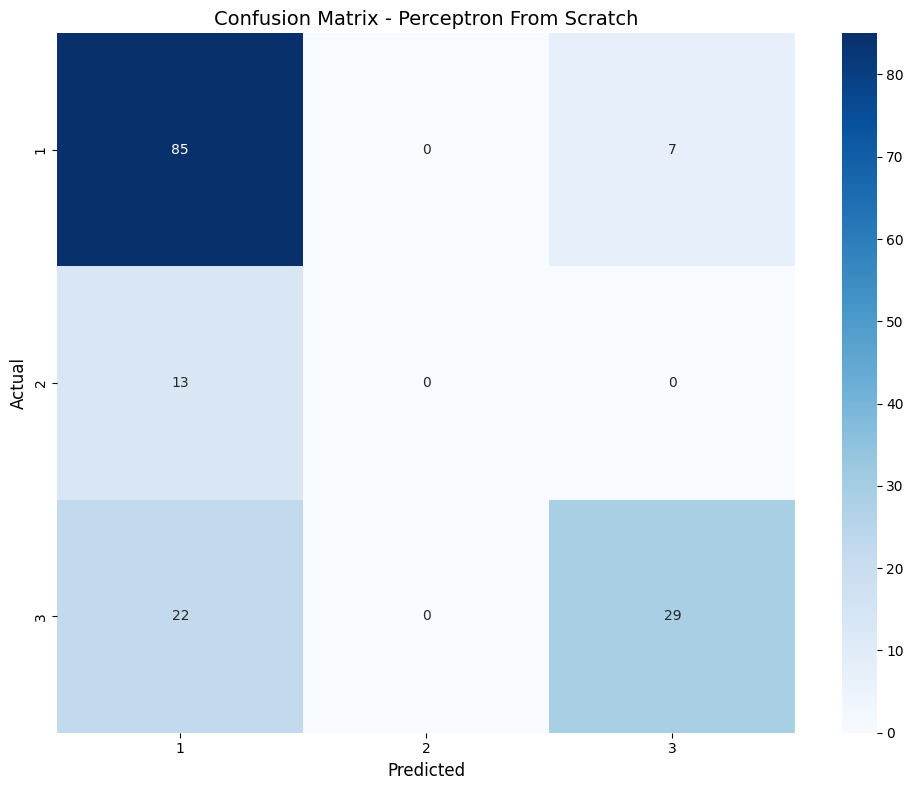

In [15]:

class PerceptronFromScratch:
    """Multi-class perceptron from scratch"""
    
    def __init__(self, learning_rate=0.01, n_iterations=1000, random_state=42):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.random_state = random_state
        self.classes_ = None
        self.weights = None
        self.bias = None
    
    def _softmax(self, z):
        """Softmax activation function"""
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    
    def fit(self, X, y):
        """Train the perceptron"""
        n_samples, n_features = X.shape
        self.classes_ = np.unique(y)
        n_classes = len(self.classes_)
        
        # Initialize weights and bias
        np.random.seed(self.random_state)
        self.weights = np.random.randn(n_features, n_classes) * 0.01
        self.bias = np.zeros((1, n_classes))
        
        # Convert y to one-hot encoding
        y_one_hot = np.zeros((n_samples, n_classes))
        y_one_hot[np.arange(n_samples), y] = 1
        
        print("Training perceptron from scratch...")
        
        # Gradient descent
        for iteration in range(self.n_iterations):
            # Forward pass
            linear_output = np.dot(X, self.weights) + self.bias
            predictions = self._softmax(linear_output)
            
            # Calculate gradient
            error = predictions - y_one_hot
            dw = np.dot(X.T, error) / n_samples
            db = np.sum(error, axis=0, keepdims=True) / n_samples
            
            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            # Print progress
            if (iteration + 1) % 200 == 0:
                loss = -np.mean(np.sum(y_one_hot * np.log(predictions + 1e-8), axis=1))
                accuracy = np.mean(np.argmax(predictions, axis=1) == y)
                print(f"  Iteration {iteration+1}/{self.n_iterations}, Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")
        
        return self
    
    def predict(self, X):
        """Predict classes"""
        linear_output = np.dot(X, self.weights) + self.bias
        predictions = self._softmax(linear_output)
        return np.argmax(predictions, axis=1)
    
    def score(self, X, y):
        """Calculate accuracy"""
        predictions = self.predict(X)
        return np.mean(predictions == y)

# Обучение модели
print("\n" + "="*60)
print("TRAINING PERCEPTRON FROM SCRATCH")
print("="*60)

custom_perceptron = PerceptronFromScratch(
    learning_rate=0.01, 
    n_iterations=1000
)
custom_perceptron.fit(X_train_scaled, y_train_int)

# Оценка
y_pred_custom = custom_perceptron.predict(X_test_scaled)
accuracy_custom = custom_perceptron.score(X_test_scaled, y_test_int)

print(f"\n{'='*60}")
print(f"RESULTS - PERCEPTRON FROM SCRATCH")
print(f"{'='*60}")
print(f"Test Accuracy: {accuracy_custom:.4f} ({accuracy_custom*100:.2f}%)")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test_int, 
    y_pred_custom, 
    target_names=class_names,
    zero_division=0
))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm_custom = confusion_matrix(y_test_int, y_pred_custom)
sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Confusion Matrix - Perceptron From Scratch', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()

Using device: cpu

TRAINING PYTORCH MLP
Epoch [20/100], Loss: 0.5399, Accuracy: 79.29%
Epoch [40/100], Loss: 0.3929, Accuracy: 82.50%
Epoch [60/100], Loss: 0.3344, Accuracy: 87.16%
Epoch [80/100], Loss: 0.3528, Accuracy: 87.32%
Epoch [100/100], Loss: 0.3424, Accuracy: 84.75%

RESULTS - PYTORCH MLP
Test Accuracy: 0.8718 (87.18%)

Classification Report:
              precision    recall  f1-score   support

           1       0.86      0.93      0.90        92
           2       0.67      0.46      0.55        13
           3       0.94      0.86      0.90        51

    accuracy                           0.87       156
   macro avg       0.82      0.75      0.78       156
weighted avg       0.87      0.87      0.87       156



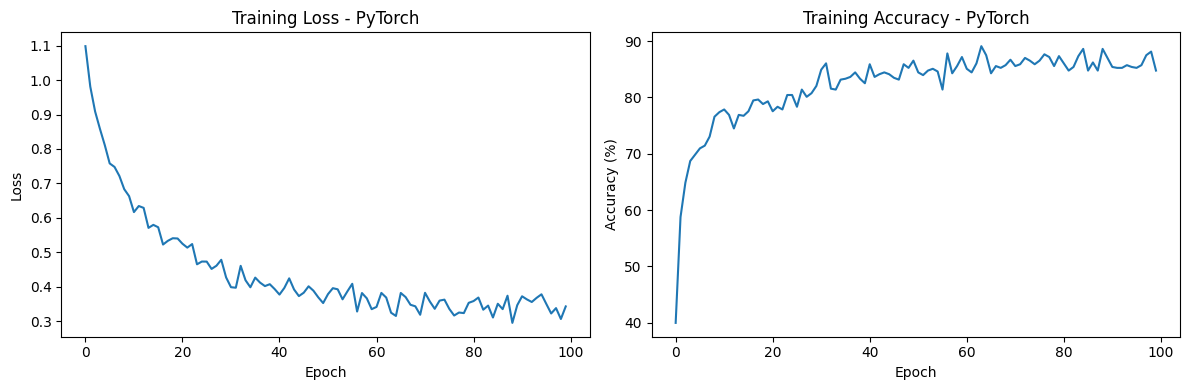

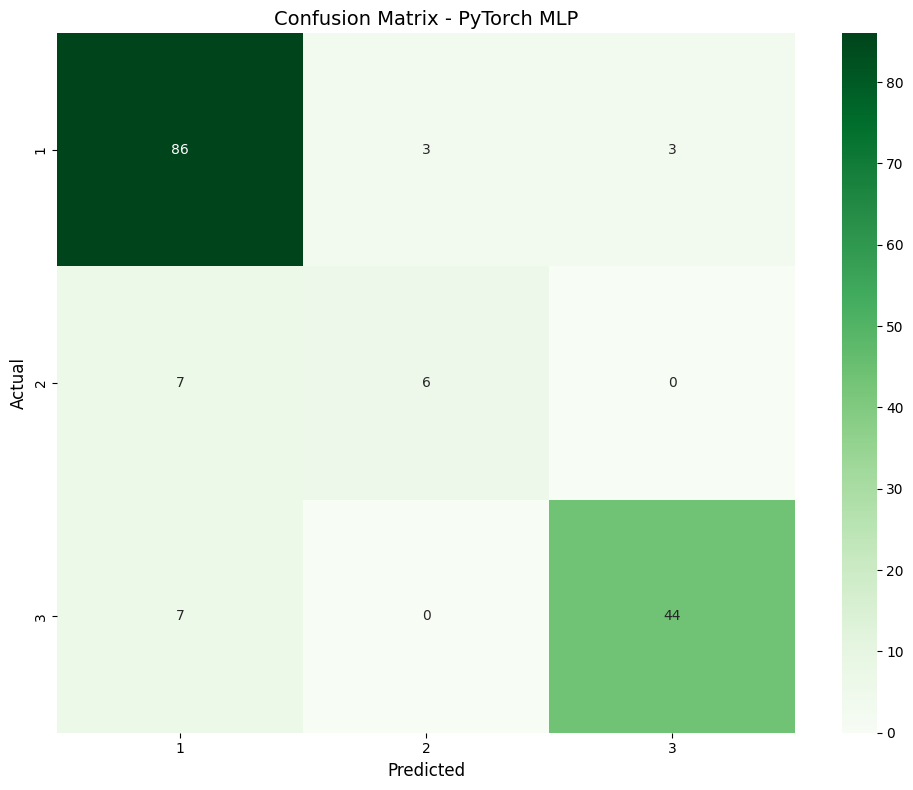

In [16]:


# Подготовка данных для PyTorch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.LongTensor(y_train_int)
y_test_tensor = torch.LongTensor(y_test_int)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Определение модели
class PyTorchMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, dropout_rate=0.2):
        super(PyTorchMLP, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            ])
            prev_dim = hidden_dim
        
        layers.append(nn.Linear(prev_dim, output_dim))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

# Параметры модели
input_dim = X_train_scaled.shape[1]
hidden_dims = [64, 32, 16]
output_dim = len(class_names)

# Инициализация
pytorch_model = PyTorchMLP(input_dim, hidden_dims, output_dim).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(pytorch_model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

# Обучение
print("\n" + "="*60)
print("TRAINING PYTORCH MLP")
print("="*60)

train_losses = []
train_accuracies = []
n_epochs = 100

for epoch in range(n_epochs):
    pytorch_model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        outputs = pytorch_model(batch_X)
        loss = criterion(outputs, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
    
    avg_loss = epoch_loss / len(train_loader)
    accuracy = 100 * correct / total
    train_losses.append(avg_loss)
    train_accuracies.append(accuracy)
    
    scheduler.step(avg_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%")

# Оценка на тестовых данных
pytorch_model.eval()
y_pred_pytorch = []
with torch.no_grad():
    correct = 0
    total = 0
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = pytorch_model(batch_X)
        _, predicted = torch.max(outputs, 1)
        y_pred_pytorch.extend(predicted.cpu().numpy())
        total += batch_y.size(0)
        correct += (predicted == batch_y).sum().item()
    
    accuracy_pytorch = correct / total

print(f"\n{'='*60}")
print(f"RESULTS - PYTORCH MLP")
print(f"{'='*60}")
print(f"Test Accuracy: {accuracy_pytorch:.4f} ({accuracy_pytorch*100:.2f}%)")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test_int, 
    y_pred_pytorch, 
    target_names=class_names,
    zero_division=0
))

# Графики обучения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_losses)
axes[0].set_title('Training Loss - PyTorch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[1].plot(train_accuracies)
axes[1].set_title('Training Accuracy - PyTorch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
plt.tight_layout()
plt.show()

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm_pytorch = confusion_matrix(y_test_int, y_pred_pytorch)
sns.heatmap(cm_pytorch, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Confusion Matrix - PyTorch MLP', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()


TRAINING TENSORFLOW MLP


E0000 00:00:1775111471.031165   33279 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775111471.031993   44301 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775111471.070061   33279 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.3213 - loss: 1.5898 - val_accuracy: 0.4480 - val_loss: 1.0701 - learning_rate: 0.0010
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4036 - loss: 1.2923 - val_accuracy: 0.5760 - val_loss: 1.0118 - learning_rate: 0.0010
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4799 - loss: 1.1221 - val_accuracy: 0.6400 - val_loss: 0.9638 - learning_rate: 0.0010
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5402 - loss: 1.0503 - val_accuracy: 0.6960 - val_loss: 0.9160 - learning_rate: 0.0010
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5321 - loss: 0.9986 - val_accuracy: 0.7360 - val_loss: 0.8812 - learning_rate: 0.0010
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6104 - loss: 0.8990 - val_accuracy: 0.7440 - val_loss: 0.8523 - learning_rate: 0.0010
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5904 - loss: 0.9457 - 

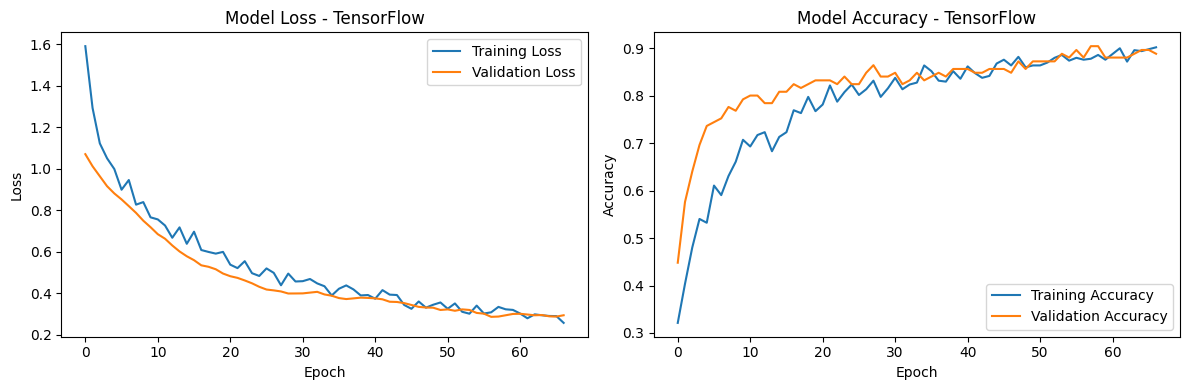

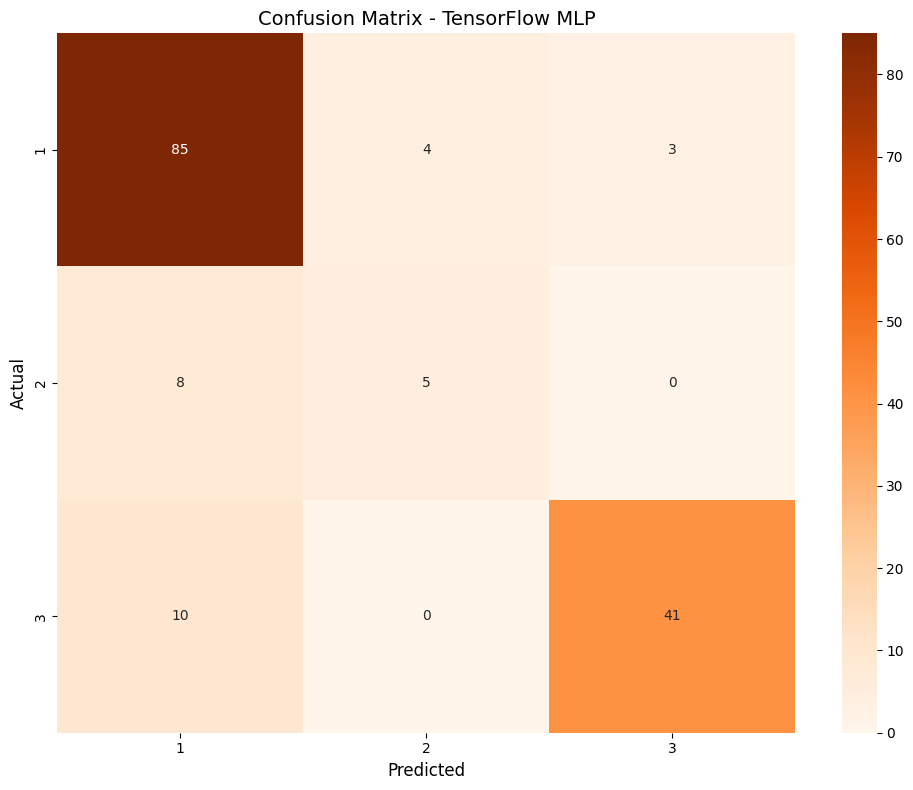

In [17]:

tf.random.set_seed(42)
np.random.seed(42)

print("\n" + "="*60)
print("TRAINING TENSORFLOW MLP")
print("="*60)

# Построение модели
tf_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    layers.Dense(16, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    
    layers.Dense(output_dim, activation='softmax')
])

# Компиляция
tf_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

# Обучение
history = tf_model.fit(
    X_train_scaled, y_train_int,
    batch_size=32,
    epochs=100,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Оценка
test_loss, test_accuracy = tf_model.evaluate(X_test_scaled, y_test_int, verbose=0)
y_pred_tf_proba = tf_model.predict(X_test_scaled)
y_pred_tf = np.argmax(y_pred_tf_proba, axis=1)

print(f"\n{'='*60}")
print(f"RESULTS - TENSORFLOW MLP")
print(f"{'='*60}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test_int, 
    y_pred_tf, 
    target_names=class_names,
    zero_division=0
))

# Графики обучения
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Model Loss - TensorFlow')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Model Accuracy - TensorFlow')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
plt.tight_layout()
plt.show()

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm_tf = confusion_matrix(y_test_int, y_pred_tf)
sns.heatmap(cm_tf, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.title('Confusion Matrix - TensorFlow MLP', fontsize=14)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.show()


MODEL COMPARISON SUMMARY
Model                     Accuracy  
-----------------------------------
Perceptron from Scratch   0.7308 (73.08%)
PyTorch MLP               0.8718 (87.18%)
TensorFlow MLP            0.8397 (83.97%)


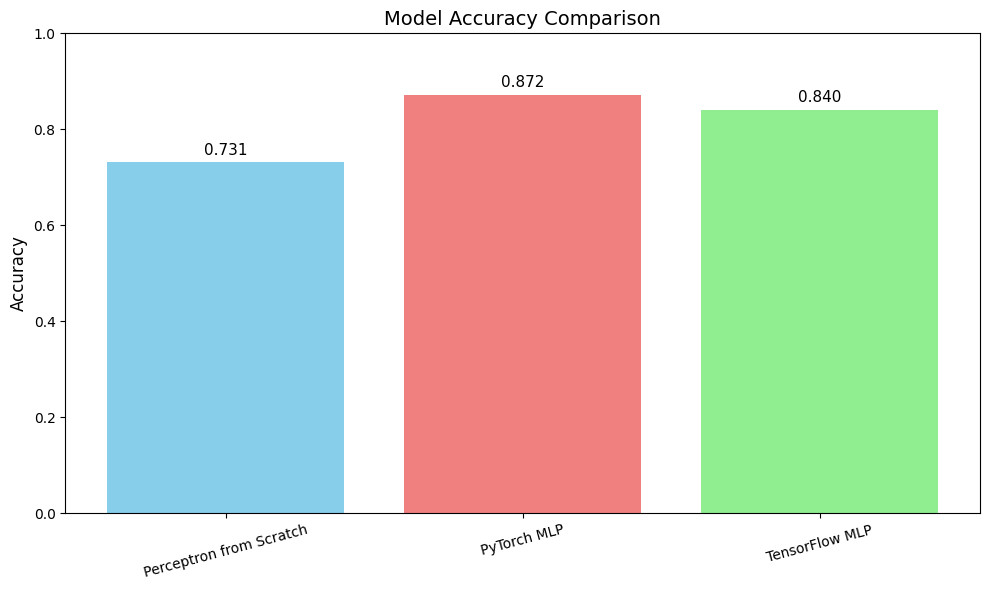

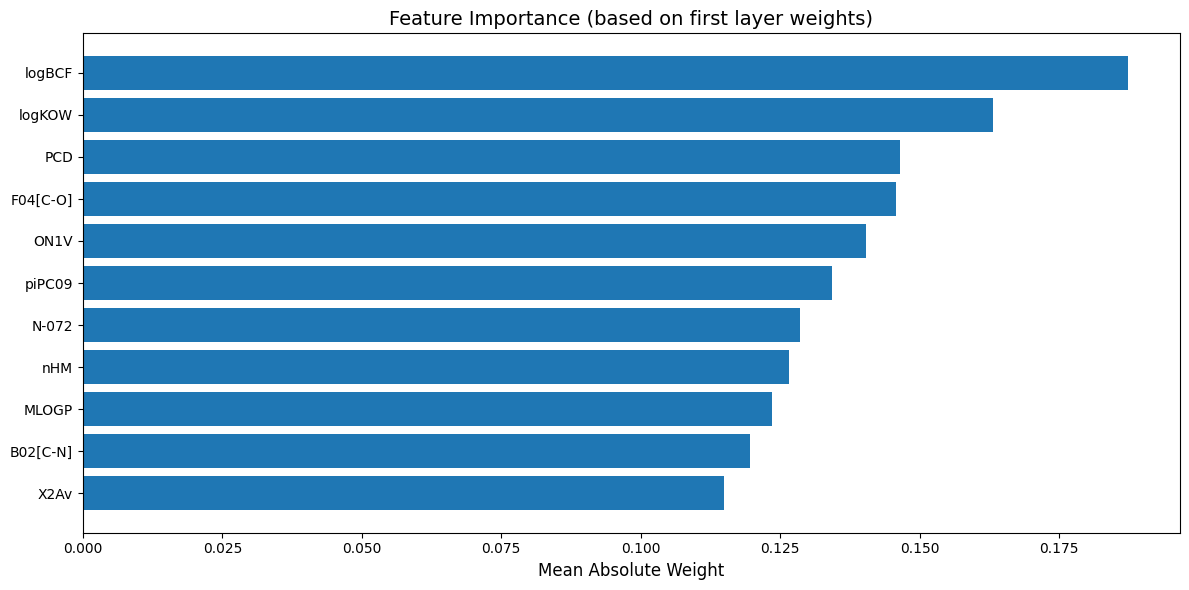


PER-CLASS ACCURACY COMPARISON

Class '1':
  Perceptron from Scratch: 0.9239
  PyTorch MLP: 0.9348
  TensorFlow MLP: 0.9239

Class '2':
  Perceptron from Scratch: 0.0000
  PyTorch MLP: 0.4615
  TensorFlow MLP: 0.3846

Class '3':
  Perceptron from Scratch: 0.5686
  PyTorch MLP: 0.8627
  TensorFlow MLP: 0.8039


In [18]:


# Сбор результатов
models_names = ['Perceptron from Scratch', 'PyTorch MLP', 'TensorFlow MLP']
accuracies = [accuracy_custom, accuracy_pytorch, test_accuracy]

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(f"{'Model':<25} {'Accuracy':<10}")
print("-"*35)
for name, acc in zip(models_names, accuracies):
    print(f"{name:<25} {acc:.4f} ({acc*100:.2f}%)")

# Визуализация сравнения
plt.figure(figsize=(10, 6))
bars = plt.bar(models_names, accuracies, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim([0, 1])
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Анализ важности признаков (для TensorFlow модели)
first_layer_weights = tf_model.layers[0].get_weights()[0]
feature_importance = np.mean(np.abs(first_layer_weights), axis=1)

plt.figure(figsize=(12, 6))
sorted_idx = np.argsort(feature_importance)
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), [feature_columns[i] for i in sorted_idx])
plt.xlabel('Mean Absolute Weight', fontsize=12)
plt.title('Feature Importance (based on first layer weights)', fontsize=14)
plt.tight_layout()
plt.show()

# Детальный анализ по классам
print("\n" + "="*60)
print("PER-CLASS ACCURACY COMPARISON")
print("="*60)

for i, class_name in enumerate(class_names):
    class_mask = (y_test_int == i)
    if np.sum(class_mask) > 0:
        acc_custom = np.mean(y_pred_custom[class_mask] == y_test_int[class_mask])
        acc_pytorch = np.mean(np.array(y_pred_pytorch)[class_mask] == y_test_int[class_mask])
        acc_tf = np.mean(y_pred_tf[class_mask] == y_test_int[class_mask])
        print(f"\nClass '{class_name}':")
        print(f"  Perceptron from Scratch: {acc_custom:.4f}")
        print(f"  PyTorch MLP: {acc_pytorch:.4f}")
        print(f"  TensorFlow MLP: {acc_tf:.4f}")